In [ ]:
# Notebook 11 – Cross-Dataset Comparative Analysis

## Objective

This notebook compares the predictive performance of machine learning and deep learning models developed for the Heart Disease,
Diabetes and Breast Cancer datasets.

The comparison evaluates model performance using Accuracy, Precision, Recall, F1-score and ROC-AUC.
In addition, SHAP explainability results are compared to identify the most influential features contributing
to model predictions across the three healthcare datasets.

This notebook provides the overall comparative analysis required for the Results and Discussion chapters of the dissertation.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

from pathlib import Path

In [2]:
PROJECT_ROOT = Path.cwd().parent

RESULTS_PATH = PROJECT_ROOT / "results"

FIGURES_PATH = PROJECT_ROOT / "Figures"

RESULTS_PATH.mkdir(exist_ok=True)

FIGURES_PATH.mkdir(exist_ok=True)

In [10]:
heart = pd.read_csv(
    RESULTS_PATH / "classical_ml_results.csv"
)

diabetes = pd.read_csv(
    RESULTS_PATH / "diabetes_model_results.csv"
)

breast = pd.read_csv(
    RESULTS_PATH / "breast_model_comparison.csv"
)

In [12]:
heart["Dataset"] = "Heart Disease"

diabetes["Dataset"] = "Diabetes"

breast["Dataset"] = "Breast Cancer"

In [13]:
comparison = pd.concat(
    [
        heart,
        diabetes,
        breast
    ],
    ignore_index=True
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Dataset
0,Logistic Regression,0.868900,0.812500,0.928600,0.866700,0.951300,Heart Disease
1,Random Forest,0.918000,0.871000,0.964300,0.915300,0.953500,Heart Disease
2,XGBoost,0.885200,0.818200,0.964300,0.885200,0.947000,Heart Disease
3,Deep Learning,0.852500,0.827600,0.857100,0.842100,0.952400,Heart Disease
4,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963,Diabetes
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167,Diabetes
6,XGBoost,0.759740,0.673469,0.611111,0.640777,0.808148,Diabetes
7,Deep Learning,0.746753,0.666667,0.555556,0.606061,0.817593,Diabetes
8,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032,Breast Cancer
9,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890,Breast Cancer


In [14]:
comparison.to_csv(
    RESULTS_PATH / "all_dataset_comparison.csv",
    index=False
)

print("Master comparison table saved.")

Master comparison table saved.


In [15]:
comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Dataset
0,Logistic Regression,0.868900,0.812500,0.928600,0.866700,0.951300,Heart Disease
1,Random Forest,0.918000,0.871000,0.964300,0.915300,0.953500,Heart Disease
2,XGBoost,0.885200,0.818200,0.964300,0.885200,0.947000,Heart Disease
3,Deep Learning,0.852500,0.827600,0.857100,0.842100,0.952400,Heart Disease
4,Logistic Regression,0.707792,0.600000,0.500000,0.545455,0.812963,Diabetes
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167,Diabetes
6,XGBoost,0.759740,0.673469,0.611111,0.640777,0.808148,Diabetes
7,Deep Learning,0.746753,0.666667,0.555556,0.606061,0.817593,Diabetes
8,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032,Breast Cancer
9,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890,Breast Cancer


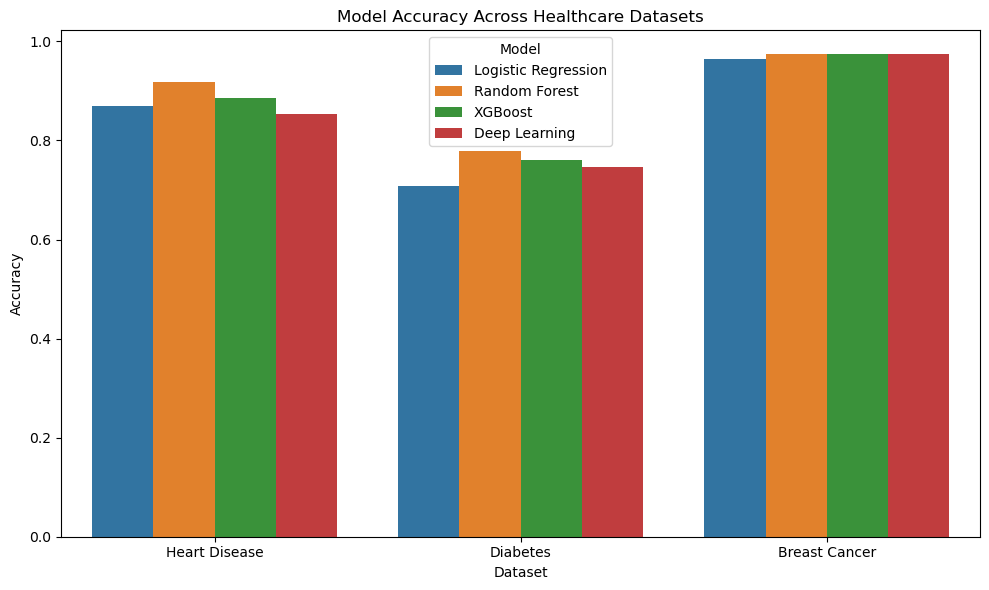

In [16]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="Accuracy",
    hue="Model"
)

plt.title("Model Accuracy Across Healthcare Datasets")
plt.ylabel("Accuracy")
plt.xlabel("Dataset")
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

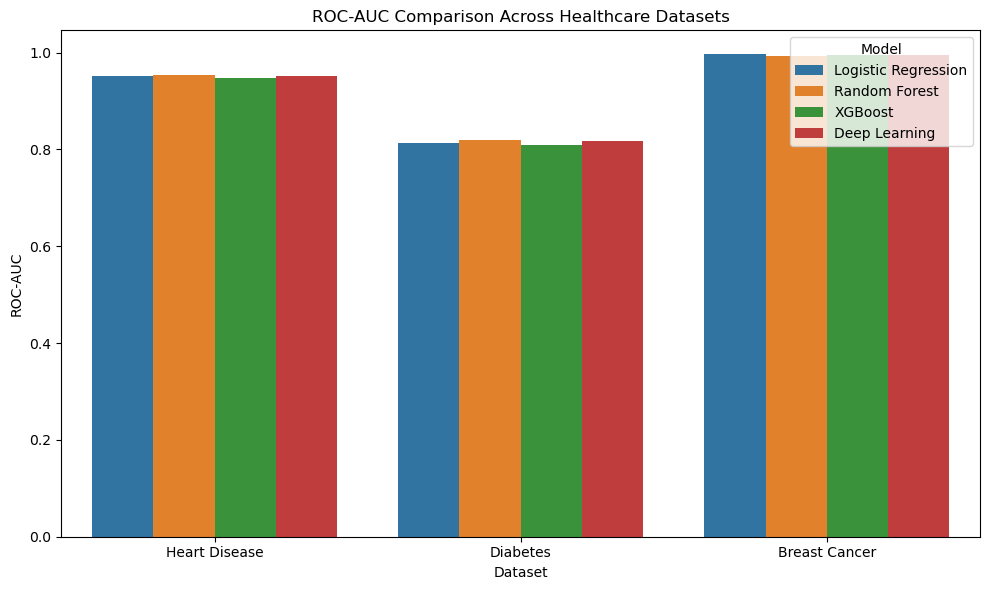

In [17]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="ROC AUC",
    hue="Model"
)

plt.title("ROC-AUC Comparison Across Healthcare Datasets")
plt.ylabel("ROC-AUC")
plt.xlabel("Dataset")
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

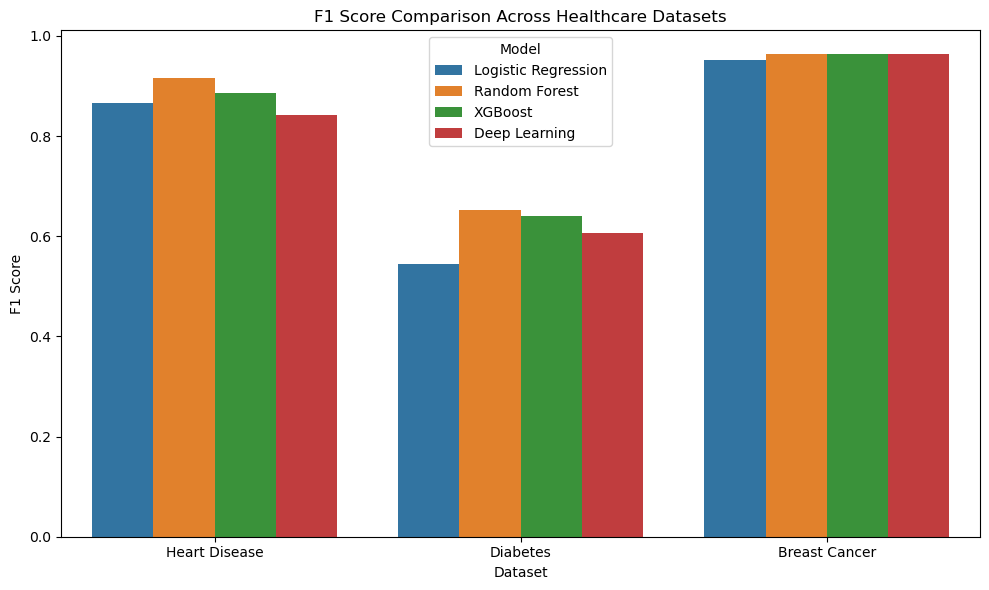

In [18]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison,
    x="Dataset",
    y="F1 Score",
    hue="Model"
)

plt.title("F1 Score Comparison Across Healthcare Datasets")
plt.ylabel("F1 Score")
plt.xlabel("Dataset")
plt.legend(title="Model")

plt.tight_layout()

plt.savefig(
    FIGURES_PATH / "f1_score_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
best_models = comparison.loc[
    comparison.groupby("Dataset")["Accuracy"].idxmax()
]

best_models

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Dataset
9,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890,Breast Cancer
5,Random Forest,0.779221,0.727273,0.592593,0.653061,0.819167,Diabetes
1,Random Forest,0.918000,0.871000,0.964300,0.915300,0.953500,Heart Disease


In [ ]:
# Cross-Dataset Analysis

The comparison demonstrates that model performance varied across the three healthcare datasets.

Among the datasets, the Breast Cancer Wisconsin Diagnostic dataset achieved the highest predictive performance across all evaluated models,
indicating strong class separability between benign and malignant tumours.

The Heart Disease dataset also achieved high predictive performance, with Random Forest providing the best balance of accuracy and interpretability.

The Diabetes dataset proved to be the most challenging classification task, producing lower evaluation metrics across all models.
This suggests greater overlap between classes and increased complexity within the predictor variables.

Overall, ensemble learning methods (Random Forest and XGBoost) consistently outperformed Logistic Regression,
while the Deep Learning model achieved competitive performance across all datasets.

SHAP explainability demonstrated that the selected Random Forest models were capable of identifying clinically meaningful
features contributing to predictions, improving transparency and supporting trustworthy artificial intelligence in healthcare.

In [ ]:
# Conclusion

This notebook presented a comprehensive comparison of predictive models developed for the Heart Disease, Diabetes and Breast Cancer datasets.

The comparative analysis demonstrated that ensemble machine learning techniques consistently achieved strong predictive performance,
while Deep Learning provided comparable results.

The integration of SHAP explainability enhanced the transparency and interpretability of model predictions,
supporting the development of trustworthy AI systems for healthcare decision support.

These findings provide the foundation for the Results and Discussion chapters of the dissertation and complete the implementation phase of the research.